In [9]:
import os
import cv2
import itertools
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

frame shape: (360, 640, 3)


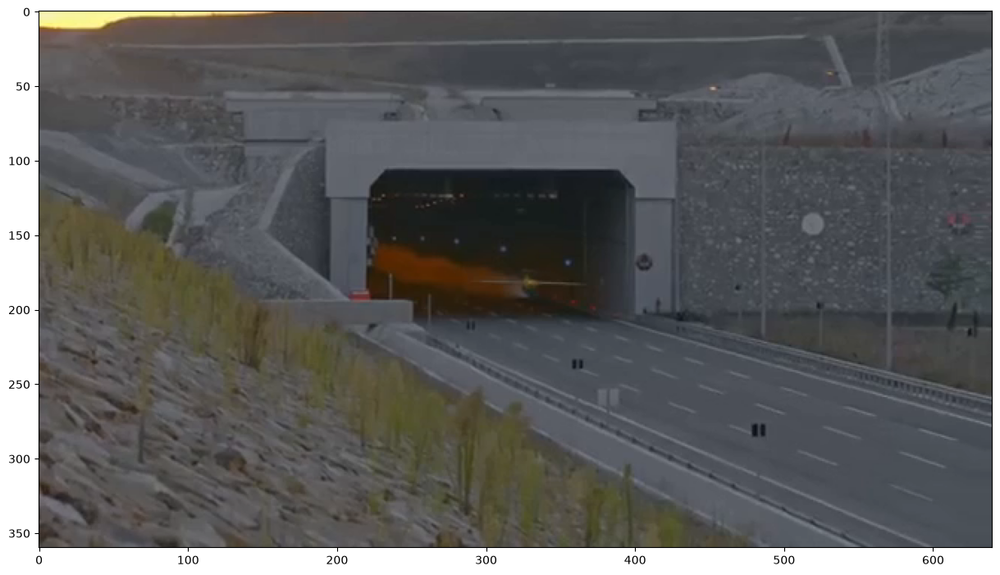

In [10]:
#load video
videoSrc = "../data/plane_cut.mp4"
cap = cv2.VideoCapture(videoSrc)
output_video_KCF = "../data/plane_KCF.mp4"
output_video_CSRT = "../data/plane_CSRT.mp4"
output_video_MIL = "../data/plane_MIL.mp4"

if not cap.isOpened():
    raise RunTimeError("Unable to open video file")
ret, first_frame = cap.read()
if not ret:
    raise RuntimeError("Unable to read frame")
    
first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
print("frame shape:", first_frame.shape)
plt.imshow(first_frame)
cap.release()

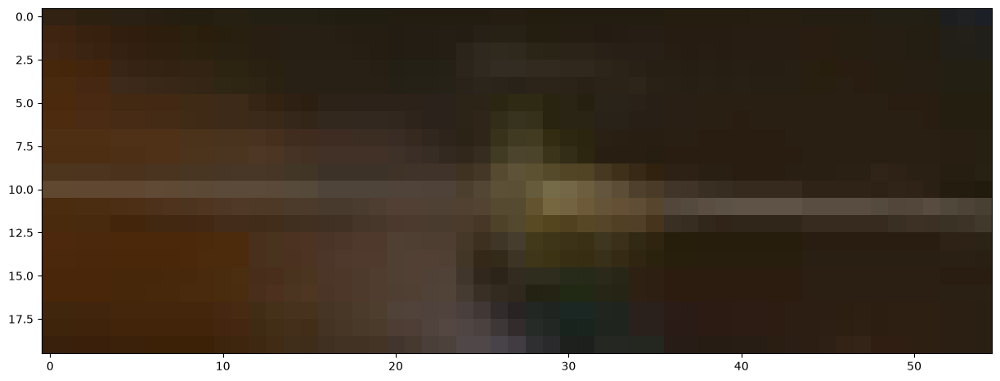

In [11]:
#lets assume that detector has found round magnet at the next coordinates
objObserved_r = 171#203#234
objObserved_c = 300#548#435
objObserved_height = 20#48
objObserved_width = 55#48

objObserved = first_frame[objObserved_r:objObserved_r + objObserved_height, objObserved_c:objObserved_c + objObserved_width]
plt.imshow(objObserved)

In [12]:
#Step 2 Init tracker
#set the search region to the size of a ball
width = objObserved_width
height = objObserved_height

#load KCF and CSRT Tracker
trackerKCF = cv2.TrackerKCF_create()
trackerCSRT = cv2.TrackerCSRT_create()
trackerMIL = cv2.TrackerMIL_create()

#prepare tracker instance
bbox = (objObserved_c, objObserved_r, width, height)
ok = trackerKCF.init(first_frame, bbox)
ok = trackerCSRT.init(first_frame, bbox)
ok = trackerMIL.init(first_frame, bbox)

In [13]:
#Step 3
#Tracking loop
def trackObject(videoSource, outVideo, tracker):
    cap = cv2.VideoCapture(videoSource)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        outVideo,
        fourcc,
        fps,
        (w, h)
    )
    
    if not cap.isOpened():
        raise RunTimeError("Unable to open video file")
    
    framesProc = []
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Video end")
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
        ok, bbox = tracker.update(frame)
        if ok:
            procFrame = frame
            #print(ok, bbox)
        
            #diplay tracker work
            x1, y1 = bbox[0], bbox[1]
            width, height = bbox[2], bbox[3]
            cv2.rectangle(procFrame, (x1, y1), (x1 + width, y1 + height), (0, 0, 255), 2)
            procFrame = cv2.cvtColor(procFrame, cv2.COLOR_RGB2BGR)
            writer.write(procFrame)
            framesProc.append(procFrame)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            writer.write(frame)
            framesProc.append(frame)

    cap.release()
    writer.release()
    return framesProc
        #plt.imshow(frame)
        #plt.show(), plt.draw()
        #plt.clf()

Video end
Video end
Video end
nKCF: 33 nCSRT: 33 MIL: 33




In [14]:
#Step 4
framesKCF = trackObject(videoSrc, output_video_KCF, trackerKCF)
framesCSRT = trackObject(videoSrc, output_video_CSRT, trackerCSRT)
framesMIL = trackObject(videoSrc, output_video_MIL, trackerMIL)

nKCF = len(framesKCF)
nCSRT = len(framesCSRT)
nMIL = len(framesMIL)
print("nKCF:", nKCF, "nCSRT:", nCSRT, "MIL:", nMIL)

fig, axes = plt.subplots(nKCF, 3, figsize=(10, 5*nKCF))
for i in range(nKCF):
    axes[i][0].imshow(framesKCF[i])
    axes[i][0].set_title(f"KCF {i}")
    axes[i][0].axis("off")

    axes[i][1].imshow(framesCSRT[i])
    axes[i][1].set_title(f"CSRT {i}")
    axes[i][1].axis("off")

    axes[i][2].imshow(framesMIL[i])
    axes[i][2].set_title(f"MIL {i}")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()